#***Machine Learning Task: House PricePrediction (Regression)***

***Problem Statement***

The real estate industry often needs accurate estimation of property prices based on various
house characteristics. In this task, the goal is to build a Machine Learning regression model
that predicts the price of a house using features such as house size, number of bedrooms,
number of bathrooms, lot size, garage size, neighborhood quality, and the year the house was
built.
Students are required to analyze the dataset, perform data preprocessing, apply feature
engineering techniques, train multiple regression models, and evaluate their performance to
identify the best model for predicting house prices.

**Objective**
The objective of this task is to:
● Understand and explore the housing dataset.

● Perform data preprocessing including handling missing values, duplicates, and outliers.

● Conduct Exploratory Data Analysis (EDA) to identify patterns and relationships in the
data.

● Apply encoding, log transformation, and feature scaling where necessary.

● Train multiple regression algorithms to predict house prices.

● Evaluate and compare model performance using appropriate evaluation metrics.

In [1]:
#import required libiraies
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


In [2]:
#loade the data set
df=pd.read_csv('house_price_regression_dataset.csv')
df.head()

,Square_Footage,Num_Bedrooms,Num_Bathrooms,Year_Built,Lot_Size,Garage_Size,Neighborhood_Quality,House_Price
0,1360,2,1,1981,0.599637,0,5,2.623829e+05
1,4272,3,3,2016,4.753014,1,6,9.852609e+05
2,3592,1,2,2016,3.634823,0,9,7.779774e+05
3,966,1,2,1977,2.730667,1,8,2.296989e+05
4,4926,2,1,1993,4.699073,0,8,1.041741e+06


df.count('Square_Footage')

In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 8 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Square_Footage        1000 non-null   int64  
 1   Num_Bedrooms          1000 non-null   int64  
 2   Num_Bathrooms         1000 non-null   int64  
 3   Year_Built            1000 non-null   int64  
 4   Lot_Size              1000 non-null   float64
 5   Garage_Size           1000 non-null   int64  
 6   Neighborhood_Quality  1000 non-null   int64  
 7   House_Price           1000 non-null   float64
dtypes: float64(2), int64(6)
memory usage: 62.6 KB


In [4]:
df.describe()

,Square_Footage,Num_Bedrooms,Num_Bathrooms,Year_Built,Lot_Size,Garage_Size,Neighborhood_Quality,House_Price
count,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1.000000e+03
mean,2815.422000,2.990000,1.973000,1986.550000,2.778087,1.022000,5.615000,6.188610e+05
std,1255.514921,1.427564,0.820332,20.632916,1.297903,0.814973,2.887059,2.535681e+05
min,503.000000,1.000000,1.000000,1950.000000,0.506058,0.000000,1.000000,1.116269e+05
25%,1749.500000,2.000000,1.000000,1969.000000,1.665946,0.000000,3.000000,4.016482e+05
50%,2862.500000,3.000000,2.000000,1986.000000,2.809740,1.000000,6.000000,6.282673e+05
75%,3849.500000,4.000000,3.000000,2004.250000,3.923317,2.000000,8.000000,8.271413e+05
max,4999.000000,5.000000,3.000000,2022.000000,4.989303,2.000000,10.000000,1.108237e+06


In [5]:
#check for missing values
df.isnull().sum()

,0
Square_Footage,0
Num_Bedrooms,0
Num_Bathrooms,0
Year_Built,0
Lot_Size,0
Garage_Size,0
Neighborhood_Quality,0
House_Price,0


In [6]:
#no missing values found

In [7]:
#check for duplicates
df.duplicated().sum()

np.int64(0)

In [8]:
#no duplicate values

In [9]:
#lets convert year to datetime
df['Year_Built']=pd.to_datetime(df["Year_Built"])


In [10]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 8 columns):
 #   Column                Non-Null Count  Dtype         
---  ------                --------------  -----         
 0   Square_Footage        1000 non-null   int64         
 1   Num_Bedrooms          1000 non-null   int64         
 2   Num_Bathrooms         1000 non-null   int64         
 3   Year_Built            1000 non-null   datetime64[ns]
 4   Lot_Size              1000 non-null   float64       
 5   Garage_Size           1000 non-null   int64         
 6   Neighborhood_Quality  1000 non-null   int64         
 7   House_Price           1000 non-null   float64       
dtypes: datetime64[ns](1), float64(2), int64(5)
memory usage: 62.6 KB


#**Univariate Analysis**

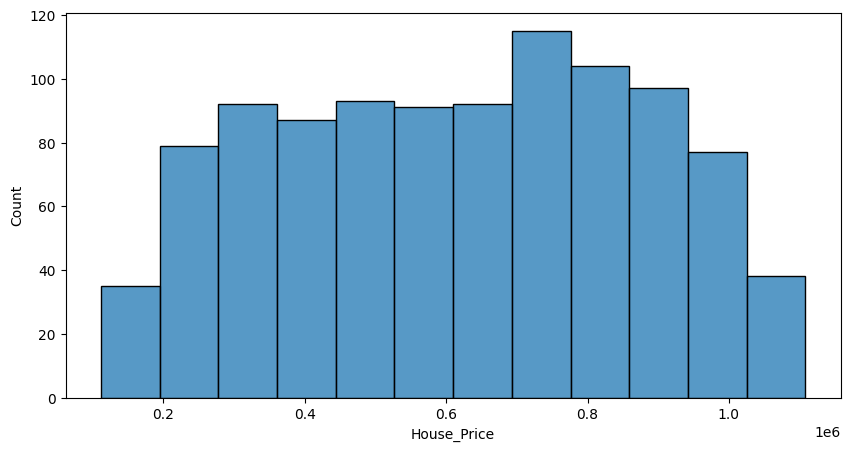

In [11]:
plt.figure(figsize=(10,5))
sns.histplot(df["House_Price"])
plt.show()

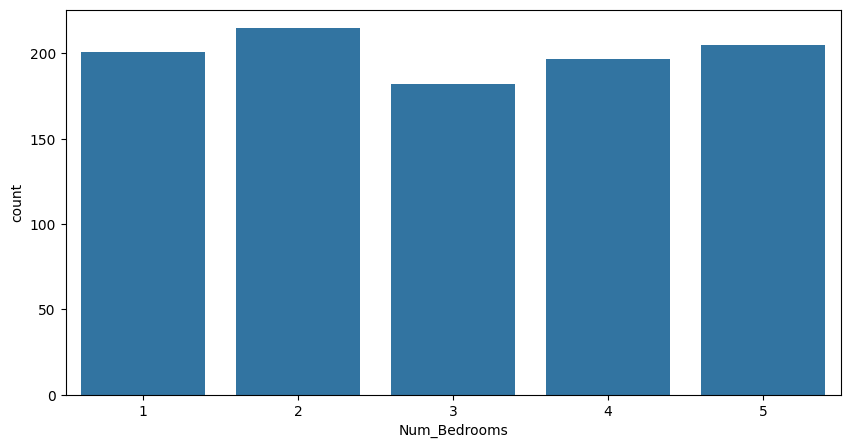

In [12]:
plt.figure(figsize=(10,5))
sns.countplot(df,x='Num_Bedrooms')
plt.show()

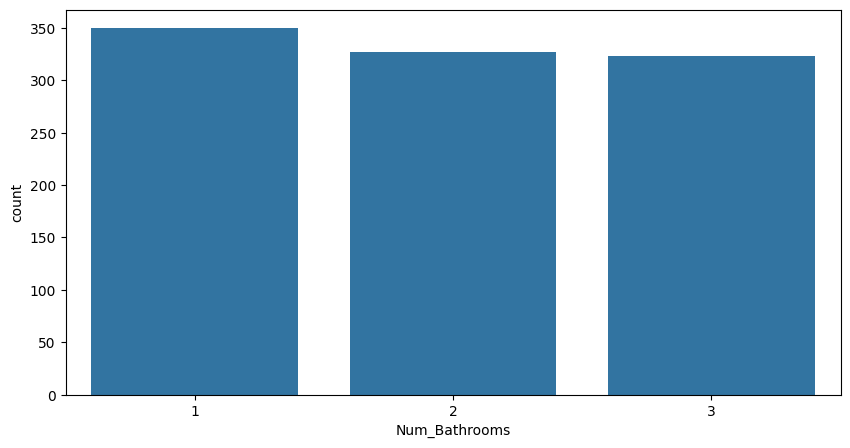

In [13]:
plt.figure(figsize=(10,5))
sns.countplot(df,x='Num_Bathrooms')
plt.show()


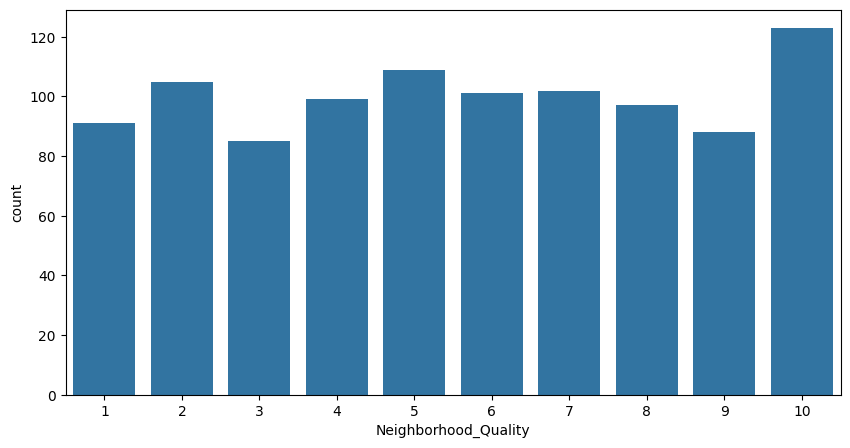

In [14]:
plt.figure(figsize=(10,5))
sns.countplot(df,x='Neighborhood_Quality')
plt.show()

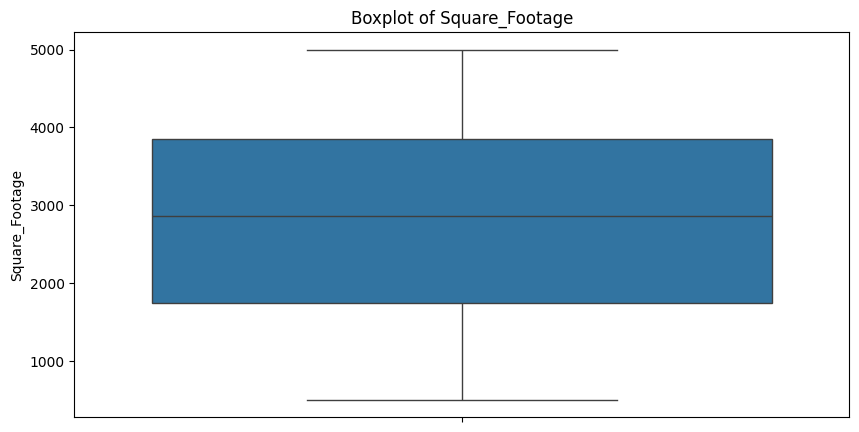

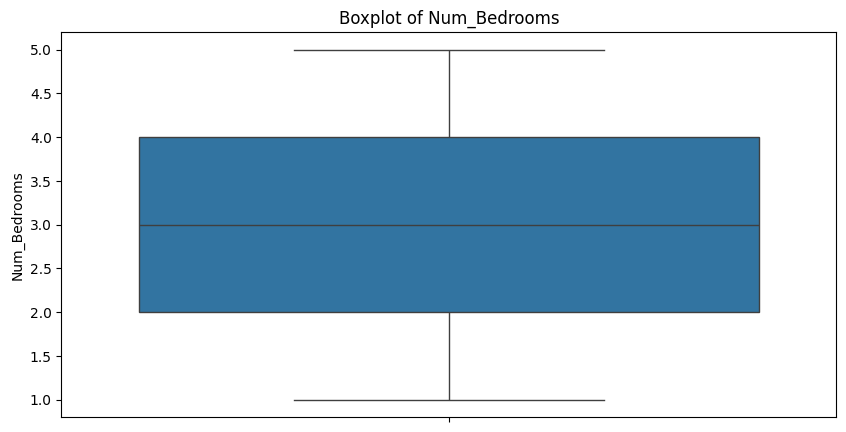

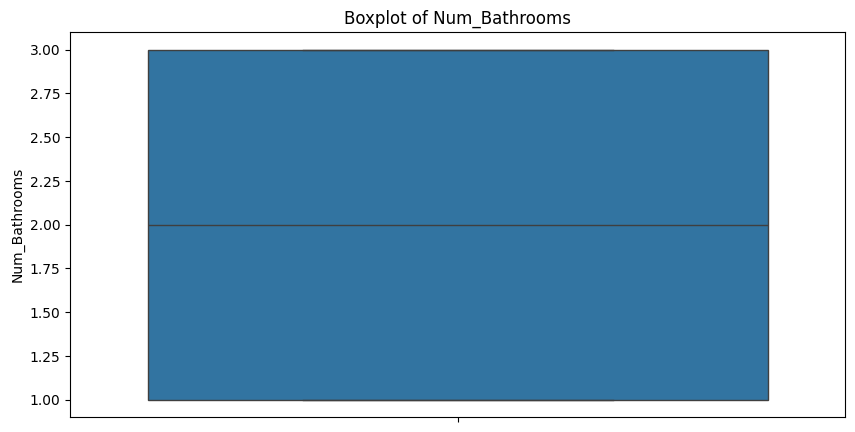

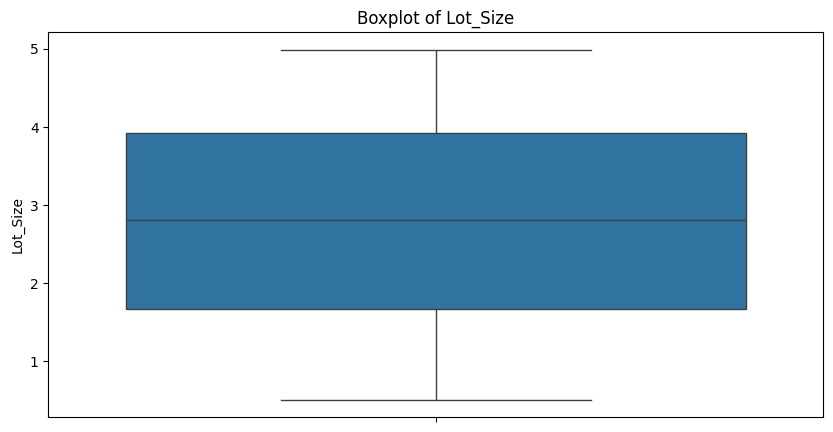

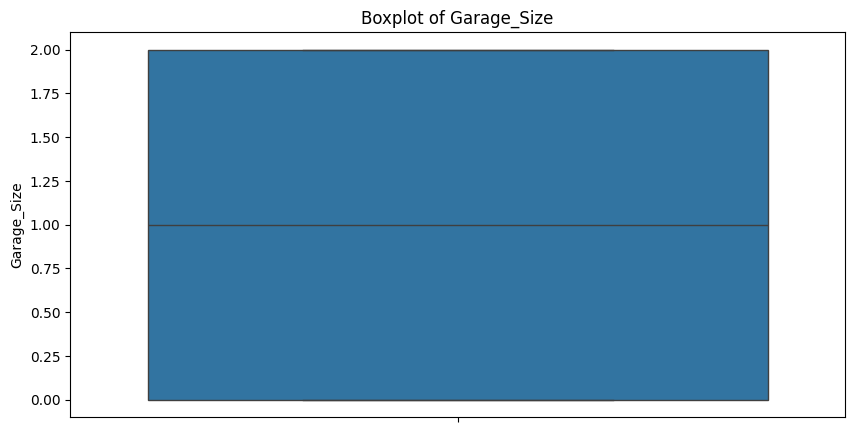

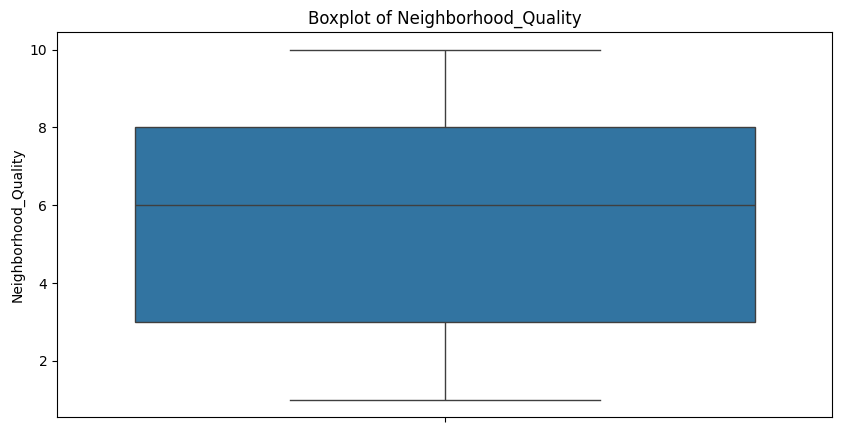

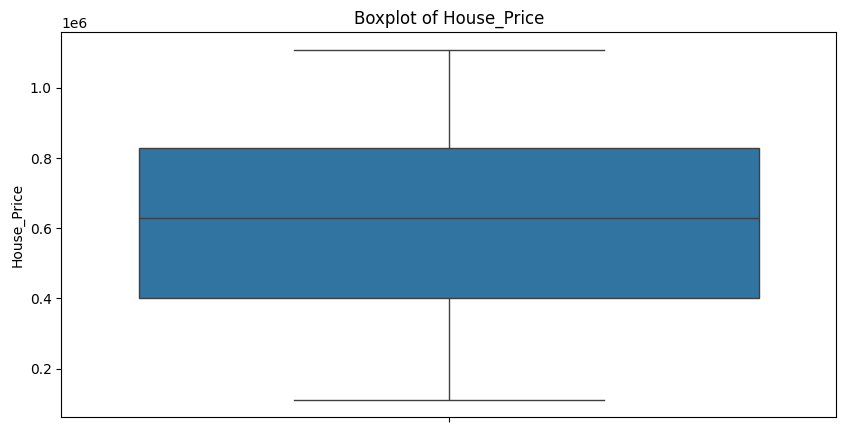

In [15]:
for column in df.columns:
    if df[column].dtype != 'datetime64[ns]': # Exclude datetime column for boxplot
        plt.figure(figsize=(10, 5))
        sns.boxplot(y=df[column])
        plt.title(f'Boxplot of {column}')
        plt.show()



###**bivariate analysis**

anylysis of 2 columns
scatter plot
bar plot
line plot

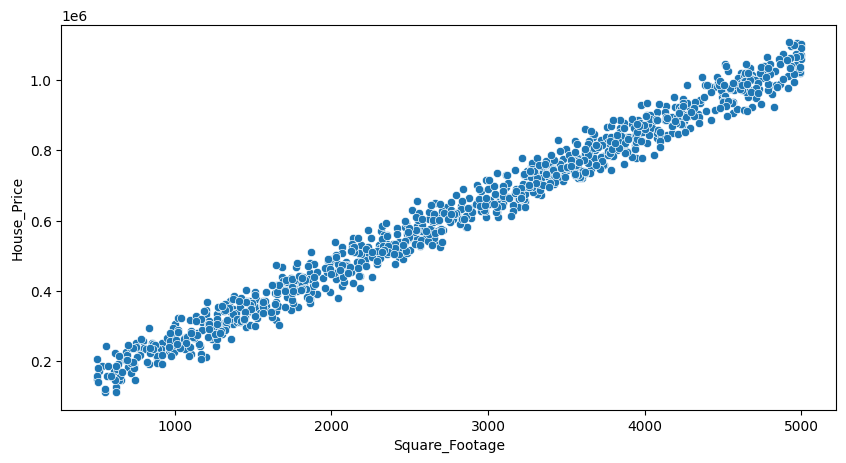

In [16]:
plt.figure(figsize=(10,5))
sns.scatterplot(y=df['House_Price'],x=df['Square_Footage'])
plt.show()

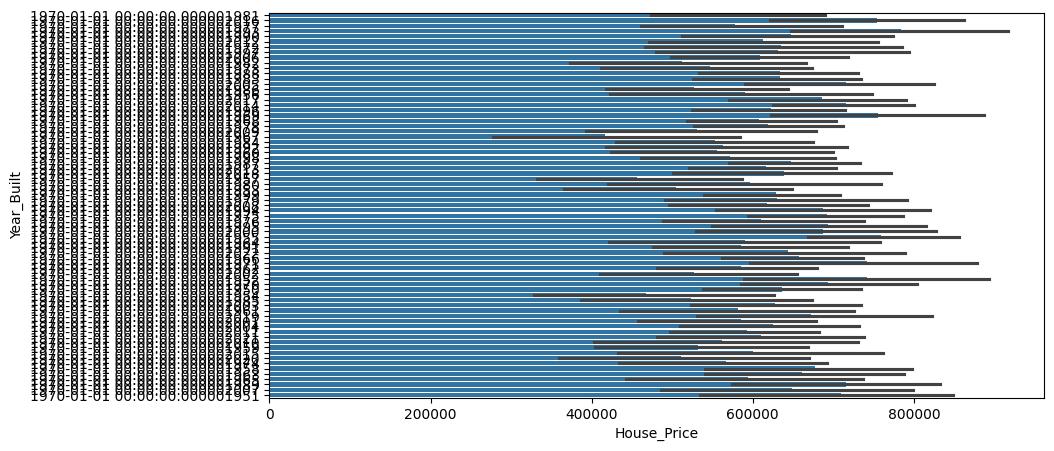

In [17]:
plt.figure(figsize=(10,5))
sns.barplot(y=df['Year_Built'],x=df['House_Price'])
plt.show()

### House Price vs. Number of Bedrooms

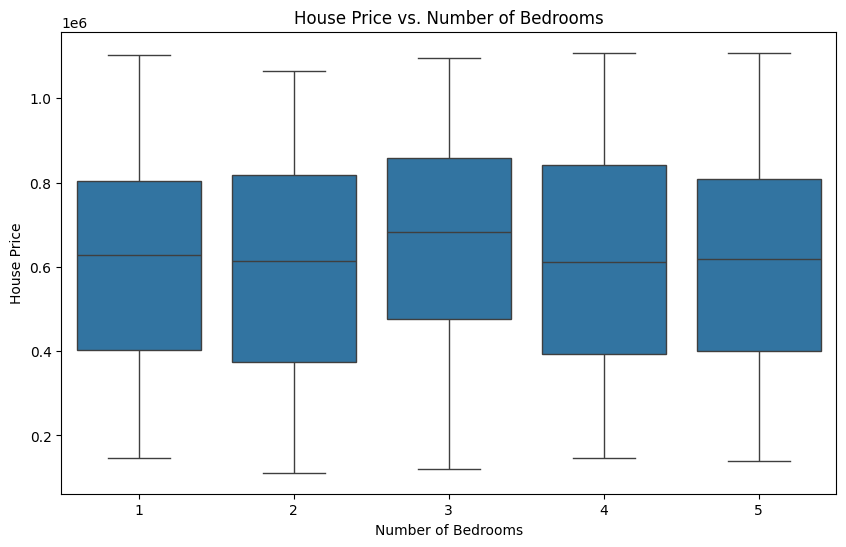

In [18]:
plt.figure(figsize=(10, 6))
sns.boxplot(x='Num_Bedrooms', y='House_Price', data=df)
plt.title('House Price vs. Number of Bedrooms')
plt.xlabel('Number of Bedrooms')
plt.ylabel('House Price')
plt.show()

### House Price vs. Number of Bathrooms

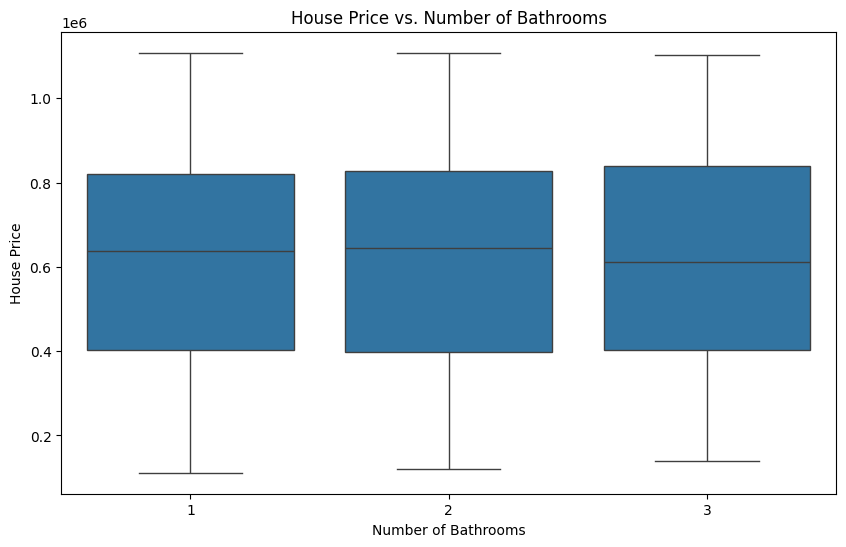

In [19]:
plt.figure(figsize=(10, 6))
sns.boxplot(x='Num_Bathrooms', y='House_Price', data=df)
plt.title('House Price vs. Number of Bathrooms')
plt.xlabel('Number of Bathrooms')
plt.ylabel('House Price')
plt.show()

### House Price vs. Lot Size

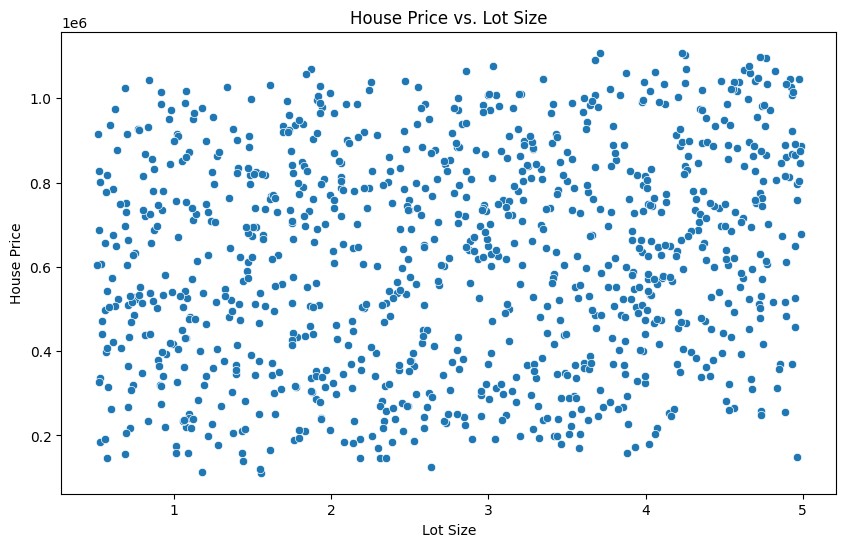

In [20]:
plt.figure(figsize=(10, 6))
sns.scatterplot(x='Lot_Size', y='House_Price', data=df)
plt.title('House Price vs. Lot Size')
plt.xlabel('Lot Size')
plt.ylabel('House Price')
plt.show()

### House Price vs. Neighborhood Quality

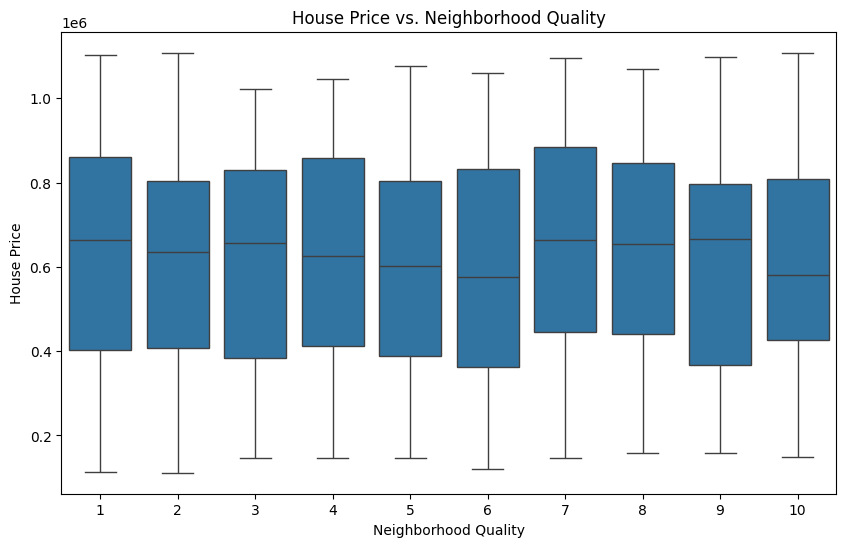

In [21]:
plt.figure(figsize=(10, 6))
sns.boxplot(x='Neighborhood_Quality', y='House_Price', data=df)
plt.title('House Price vs. Neighborhood Quality')
plt.xlabel('Neighborhood Quality')
plt.ylabel('House Price')
plt.show()

### Correlation Matrix

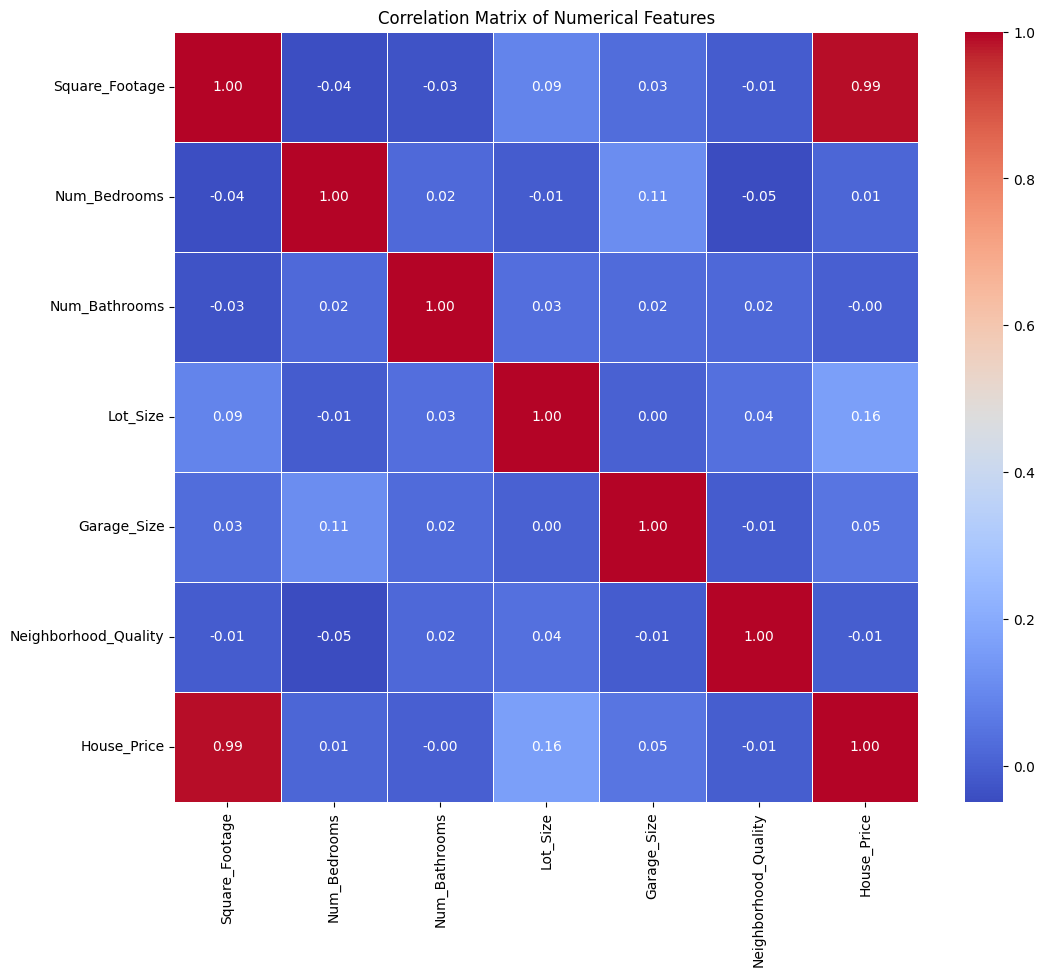

In [22]:
# Calculate the correlation matrix for numerical columns
correlation_matrix = df.select_dtypes(include=np.number).corr()

# Plot the heatmap
plt.figure(figsize=(12, 10))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt='.2f', linewidths=.5)
plt.title('Correlation Matrix of Numerical Features')
plt.show()

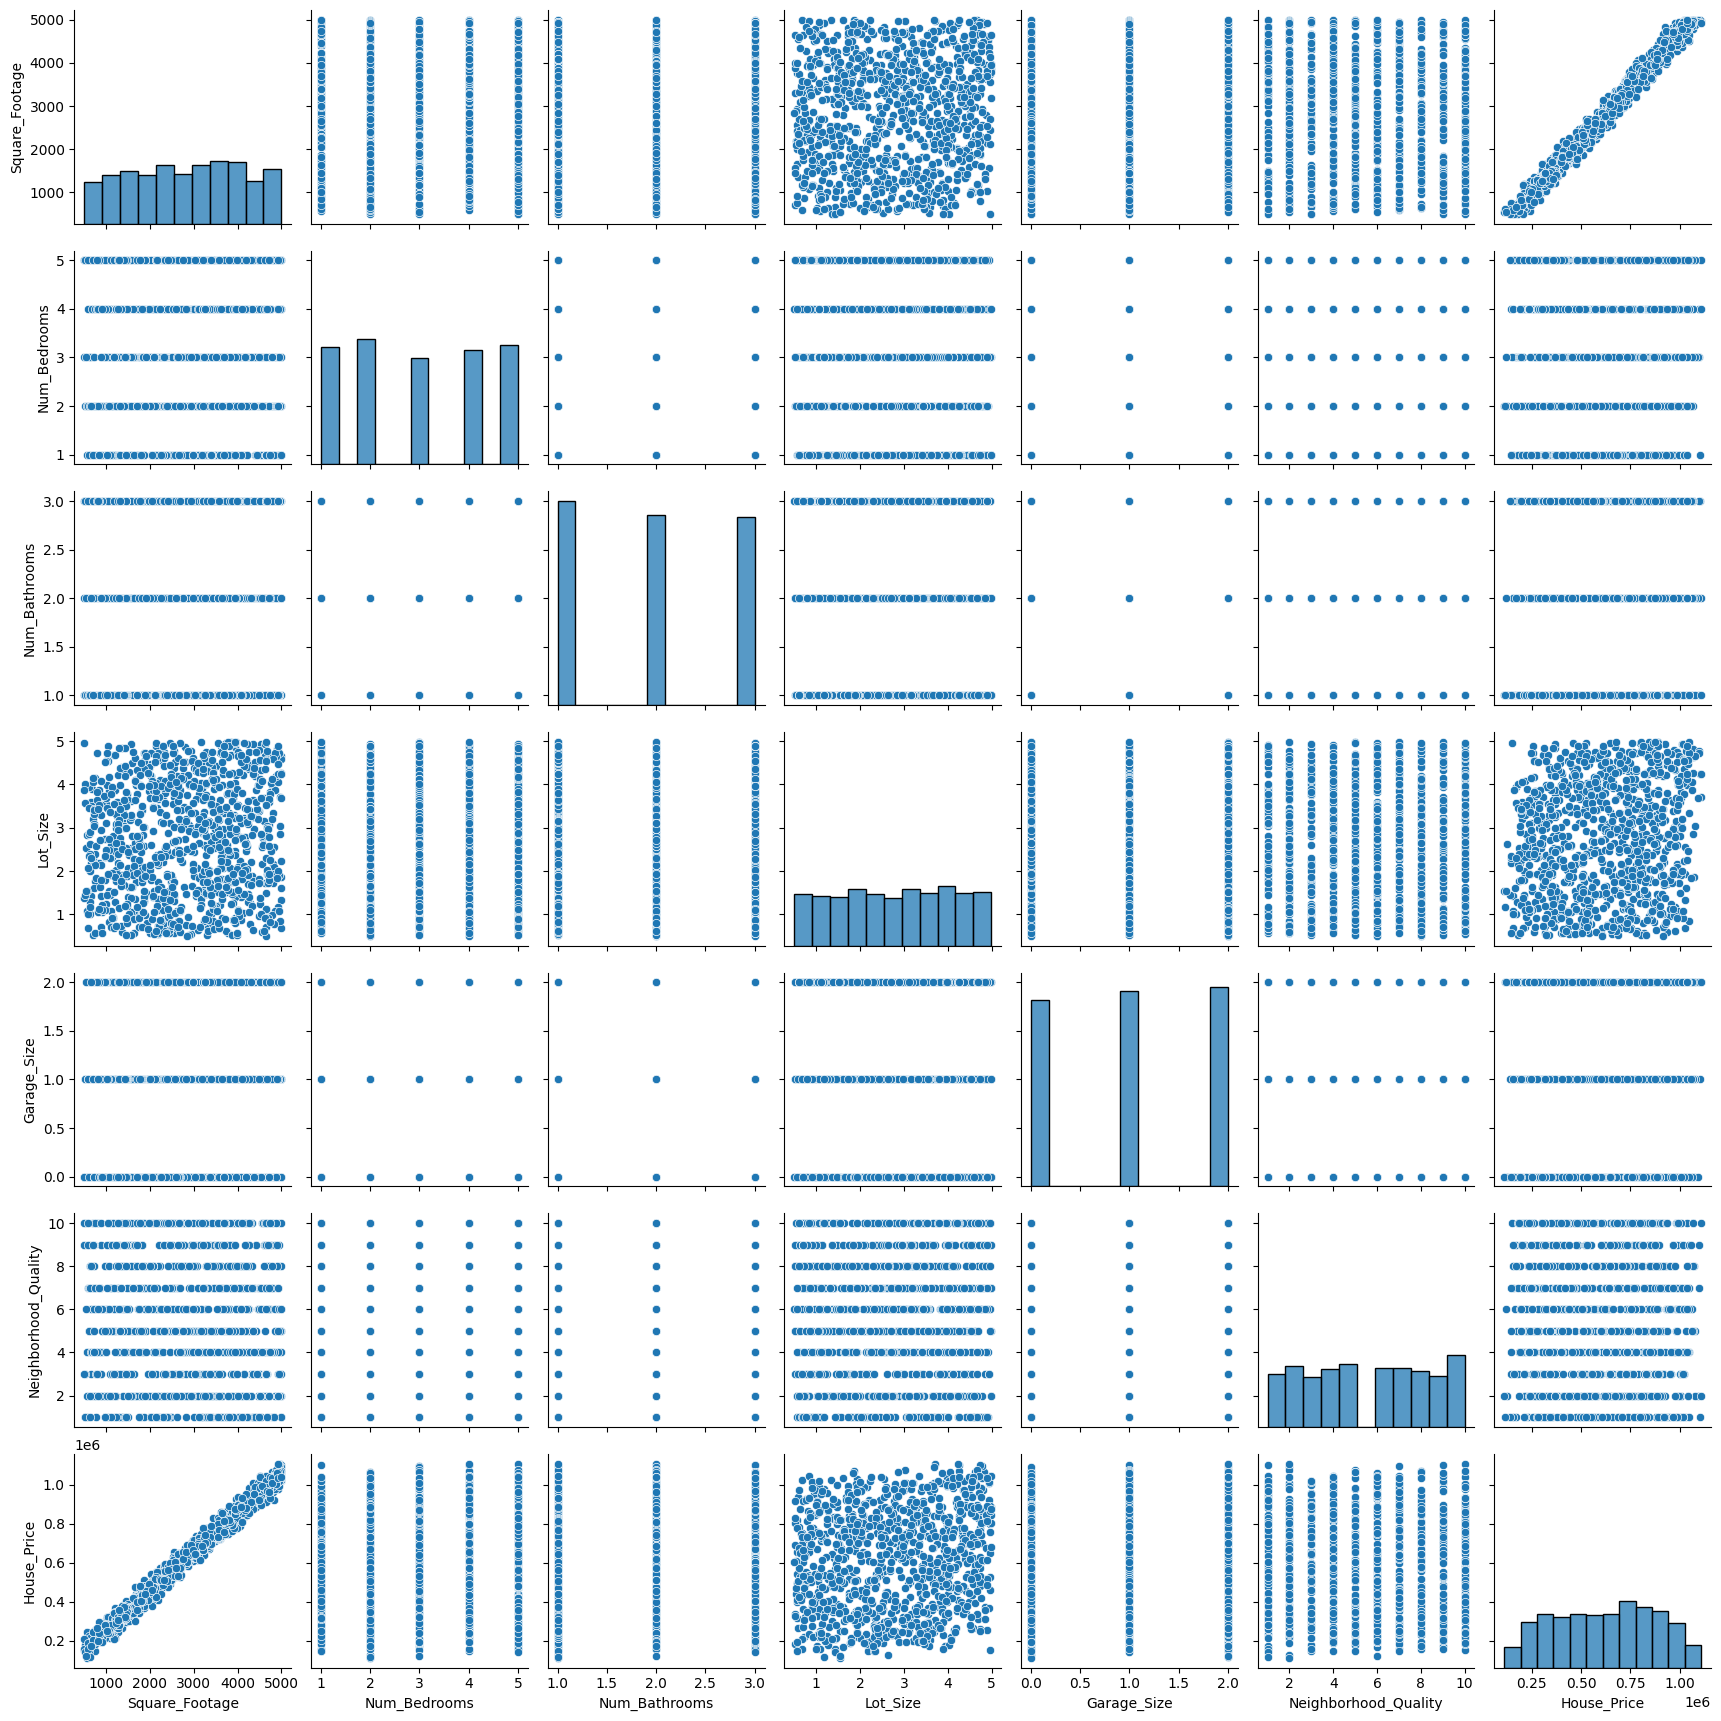

In [23]:
sns.pairplot(df)
plt.show()

#**Detect and Handle Outliers**

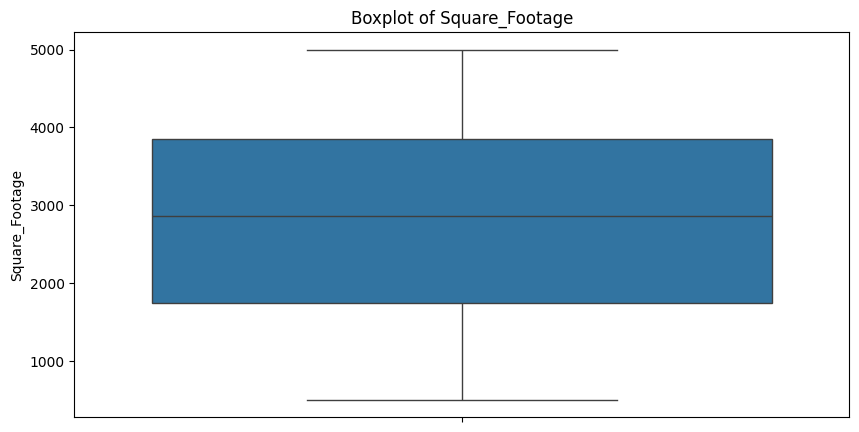

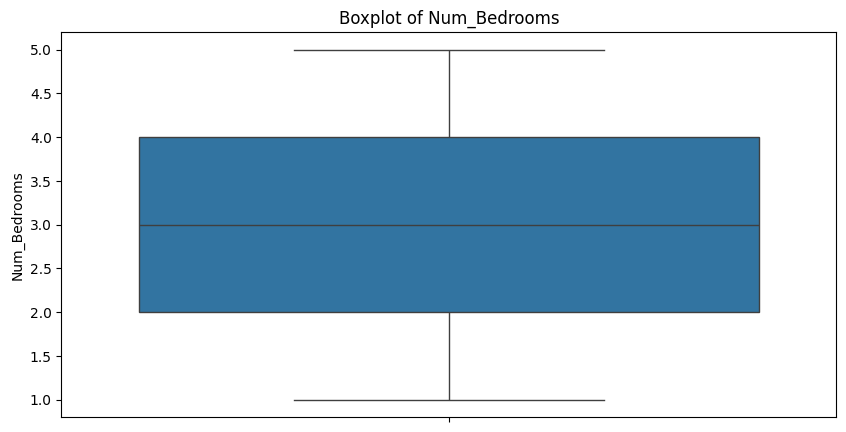

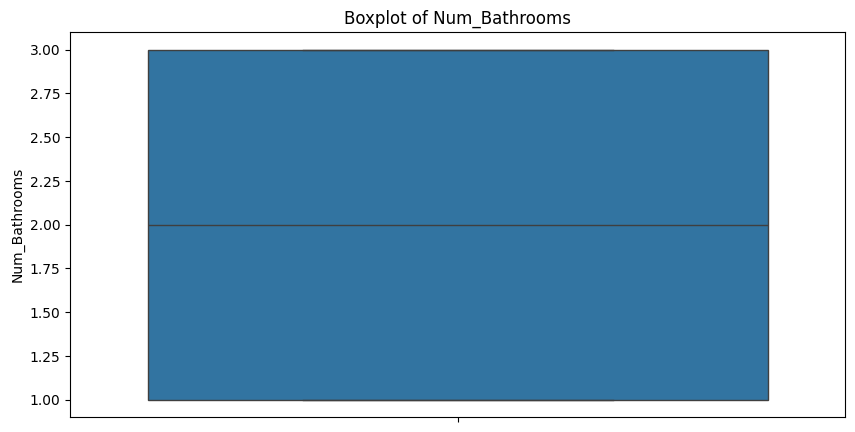

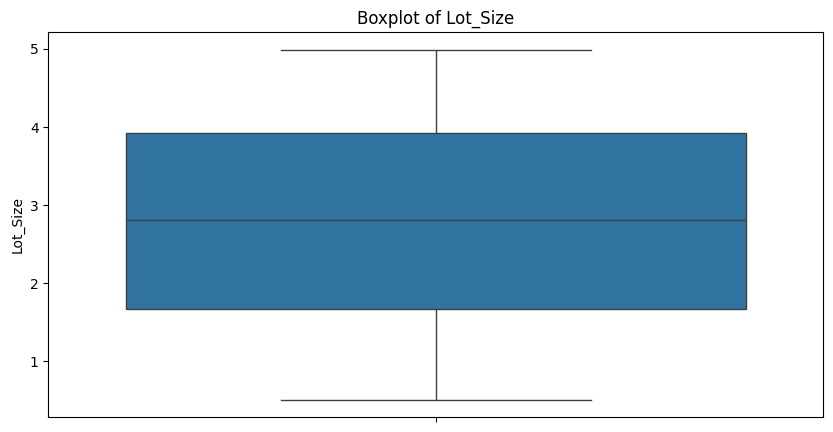

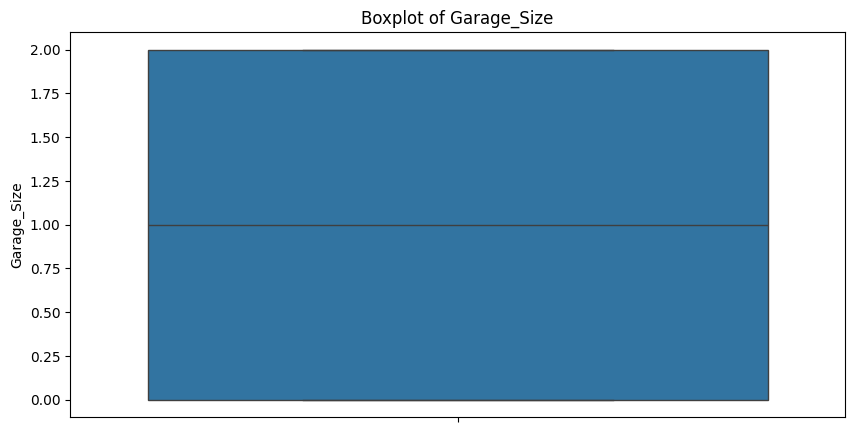

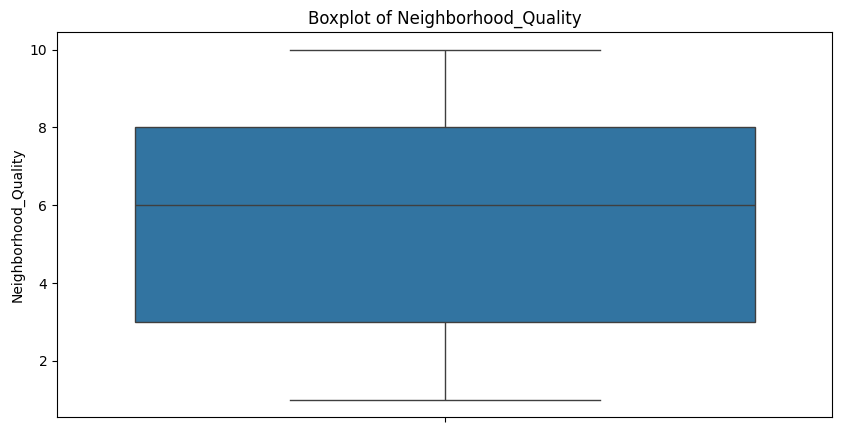

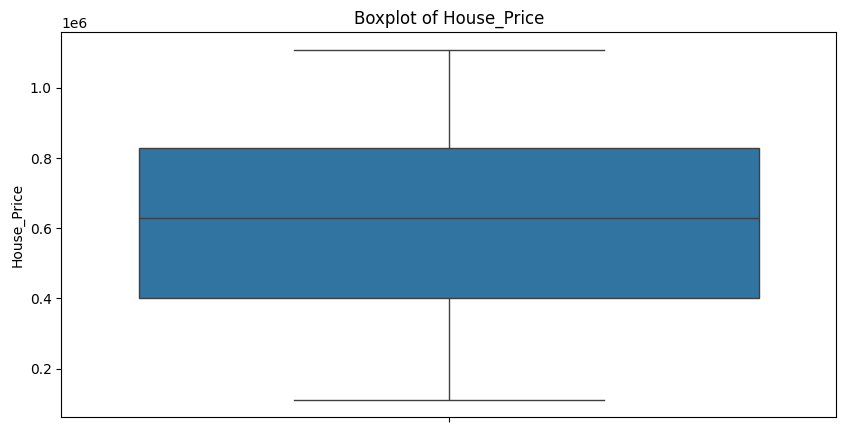

In [24]:
for column in df.columns:
    if df[column].dtype != 'datetime64[ns]': # Exclude datetime column for boxplot
        plt.figure(figsize=(10, 5))
        sns.boxplot(y=df[column])
        plt.title(f'Boxplot of {column}')
        plt.show()

In [25]:
#no outliers present as priviously seen in boxplot

### Feature Engineering: Convert `Year_Built` to `House_Age`

In [26]:
from datetime import datetime

df['House_Age'] = datetime.now().year - df['Year_Built'].dt.year
df = df.drop('Year_Built', axis=1)
display(df.head())

,Square_Footage,Num_Bedrooms,Num_Bathrooms,Lot_Size,Garage_Size,Neighborhood_Quality,House_Price,House_Age
0,1360,2,1,0.599637,0,5,2.623829e+05,56
1,4272,3,3,4.753014,1,6,9.852609e+05,56
2,3592,1,2,3.634823,0,9,7.779774e+05,56
3,966,1,2,2.730667,1,8,2.296989e+05,56
4,4926,2,1,4.699073,0,8,1.041741e+06,56


In [27]:
x = df.drop('House_Price', axis=1)
y = df['House_Price']

print("Features (X) shape:", x.shape)
print("Target (y) shape:", y.shape)

display(x.head())
display(y.head())

Features (X) shape: (1000, 7)
Target (y) shape: (1000,)


,Square_Footage,Num_Bedrooms,Num_Bathrooms,Lot_Size,Garage_Size,Neighborhood_Quality,House_Age
0,1360,2,1,0.599637,0,5,56
1,4272,3,3,4.753014,1,6,56
2,3592,1,2,3.634823,0,9,56
3,966,1,2,2.730667,1,8,56
4,4926,2,1,4.699073,0,8,56


,House_Price
0,2.623829e+05
1,9.852609e+05
2,7.779774e+05
3,2.296989e+05
4,1.041741e+06


### Train-Test Split

In [28]:
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test=train_test_split(x,y)

In [30]:
from sklearn.preprocessing import StandardScaler


numerical_cols = ['Square_Footage', 'Lot_Size']

scaler = StandardScaler()

# Fit on training data and transform both training and test data
x_train[numerical_cols] = scaler.fit_transform(x_train[numerical_cols])
x_test[numerical_cols] = scaler.transform(x_test[numerical_cols])

print("Scaled X_train head:")
display(x_train.head())
print("Scaled X_test head:")
display(x_test.head())

Scaled X_train head:


,Square_Footage,Num_Bedrooms,Num_Bathrooms,Lot_Size,Garage_Size,Neighborhood_Quality,House_Age
818,-0.820890,2,2,-1.415859,2,4,56
806,1.375073,2,1,0.059674,1,6,56
424,-0.118403,3,1,1.401607,0,5,56
315,0.290129,3,2,-1.081702,0,6,56
561,1.719599,2,3,0.059626,1,5,56


Scaled X_test head:


,Square_Footage,Num_Bedrooms,Num_Bathrooms,Lot_Size,Garage_Size,Neighborhood_Quality,House_Age
970,1.567881,3,3,0.316819,2,7,56
440,1.633468,5,2,0.833996,0,6,56
254,0.215061,3,1,-0.994263,2,10,56
250,-0.069411,1,3,1.007658,2,8,56
289,0.405499,3,1,-0.698518,2,2,56


## 1. Linear Regression Model

In [33]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
import numpy as np

# Initialize and train the Linear Regression model
linear_reg = LinearRegression()
linear_reg.fit(x_train, y_train)

# Make predictions on the test set
y_pred_lr = linear_reg.predict(x_test)

# Evaluate the model
r2_lr = r2_score(y_test, y_pred_lr)
mae_lr = mean_absolute_error(y_test, y_pred_lr)
mse_lr = mean_squared_error(y_test, y_pred_lr)
rmse_lr = np.sqrt(mse_lr)

# Calculate MAPE
mape_lr = np.mean(np.abs((y_test - y_pred_lr) / y_test)) * 100

# Calculate Adjusted R-squared
n_lr = x_test.shape[0]  # Number of samples
p_lr = x_test.shape[1]  # Number of features
adj_r2_lr = 1 - (1 - r2_lr) * (n_lr - 1) / (n_lr - p_lr - 1)

print("Linear Regression Performance:")
print(f"R-squared: {r2_lr:.4f}")
print(f"Adjusted R-squared: {adj_r2_lr:.4f}")
print(f"Mean Absolute Error (MAE): {mae_lr:.2f}")
print(f"Mean Squared Error (MSE): {mse_lr:.2f}")
print(f"Root Mean Squared Error (RMSE): {rmse_lr:.2f}")
print(f"Mean Absolute Percentage Error (MAPE): {mape_lr:.2f}%")

Linear Regression Performance:
R-squared: 0.9918
Adjusted R-squared: 0.9915
Mean Absolute Error (MAE): 18777.36
Mean Squared Error (MSE): 495910157.26
Root Mean Squared Error (RMSE): 22269.04
Mean Absolute Percentage Error (MAPE): 3.57%


## 2. K-Nearest Neighbors (KNN) Regression Model

In [34]:
from sklearn.neighbors import KNeighborsRegressor


# Initialize and train the KNN Regressor model
# You might want to experiment with different 'n_neighbors' values
knn_reg = KNeighborsRegressor(n_neighbors=5) # Using 5 neighbors as a starting point
knn_reg.fit(x_train, y_train)

# Make predictions on the test set
y_pred_knn = knn_reg.predict(x_test)

# Evaluate the model
r2_knn = r2_score(y_test, y_pred_knn)
mae_knn = mean_absolute_error(y_test, y_pred_knn)
mse_knn = mean_squared_error(y_test, y_pred_knn)
rmse_knn = np.sqrt(mse_knn)

# Calculate MAPE
mape_knn = np.mean(np.abs((y_test - y_pred_knn) / y_test)) * 100

# Calculate Adjusted R-squared
n_knn = x_test.shape[0]  # Number of samples
p_knn = x_test.shape[1]  # Number of features
adj_r2_knn = 1 - (1 - r2_knn) * (n_knn - 1) / (n_knn - p_knn - 1)

print("KNN Regression Performance:")
print(f"R-squared: {r2_knn:.4f}")
print(f"Adjusted R-squared: {adj_r2_knn:.4f}")
print(f"Mean Absolute Error (MAE): {mae_knn:.2f}")
print(f"Mean Squared Error (MSE): {mse_knn:.2f}")
print(f"Root Mean Squared Error (RMSE): {rmse_knn:.2f}")
print(f"Mean Absolute Percentage Error (MAPE): {mape_knn:.2f}%")

KNN Regression Performance:
R-squared: 0.8997
Adjusted R-squared: 0.8968
Mean Absolute Error (MAE): 61977.37
Mean Squared Error (MSE): 6057758744.10
Root Mean Squared Error (RMSE): 77831.61
Mean Absolute Percentage Error (MAPE): 12.26%


In [35]:
!git clone https://github.com/Kif30/real-estate-price-predictor.git

fatal: destination path 'real-estate-price-predictor' already exists and is not an empty directory.


In [ ]:
import shutil
shutil.copy('/content/NAME_OF_NOTEBOOK.ipynb',
            '/content/real-estate-price-predictor')